<a href="https://colab.research.google.com/github/aamna18/End-to-End-Supervised-Machine-Learning-System-for-Intrusion-Detection/blob/main/CS23016_dataset_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SUBMITTED BY:

---


AMNA AHMED CS-23016




ABDUL WAHAB CS-23035

WALEED AHMED KHAN CS-23044



## EXTENDED DATASET ANALYSIS

This notebook performs an extended data analysis on the provided `ids_dataset_ready_for_ml.csv` dataset. It covers basic information, data quality checks, class distribution, statistical summaries, skewness, kurtosis, feature correlation with the 'Label' (target variable), class-wise feature separation, distribution overlays, outlier analysis, PCA visualization for separability, and identification of highly correlated features. The goal is to understand the dataset's characteristics and identify key features that distinguish between normal and attack traffic.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv("ids_dataset_ready_for_ml.csv")

## 1. BASIC INFO

In [ ]:
print("\n===== BASIC INFO =====")
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())


===== BASIC INFO =====
Shape: (11051, 26)

Columns:
 ['total_packets', 'total_bytes', 'flow_duration_sec', 'bytes_per_sec', 'pkts_per_sec', 'pkt_len_mean', 'pkt_len_std', 'pkt_len_min', 'pkt_len_max', 'iat_mean', 'iat_std', 'iat_min', 'iat_max', 'syn_count', 'ack_count', 'fin_count', 'rst_count', 'syn_ack_ratio', 'ttl_mean', 'window_size_mean', 'retransmission_count', 'proto_tcp', 'proto_udp', 'proto_icmp', 'proto_other', 'Label']


## 2. DATA QUALITY CHECK

In [ ]:
print("\n===== DATA QUALITY =====")
print("Missing values:\n", df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

# Infinite values check
print("Infinite values:", np.isinf(df.select_dtypes(include=[np.number])).sum().sum())


===== DATA QUALITY =====
Missing values:
 total_packets           0
total_bytes             0
flow_duration_sec       0
bytes_per_sec           0
pkts_per_sec            0
pkt_len_mean            0
pkt_len_std             0
pkt_len_min             0
pkt_len_max             0
iat_mean                0
iat_std                 0
iat_min                 0
iat_max                 0
syn_count               0
ack_count               0
fin_count               0
rst_count               0
syn_ack_ratio           0
ttl_mean                0
window_size_mean        0
retransmission_count    0
proto_tcp               0
proto_udp               0
proto_icmp              0
proto_other             0
Label                   0
dtype: int64
Duplicates: 0
Infinite values: 0


## 3. CLASS DISTRIBUTION


===== CLASS DISTRIBUTION =====
Label
1    5840
0    5211
Name: count, dtype: int64
Label
1    0.528459
0    0.471541
Name: proportion, dtype: float64


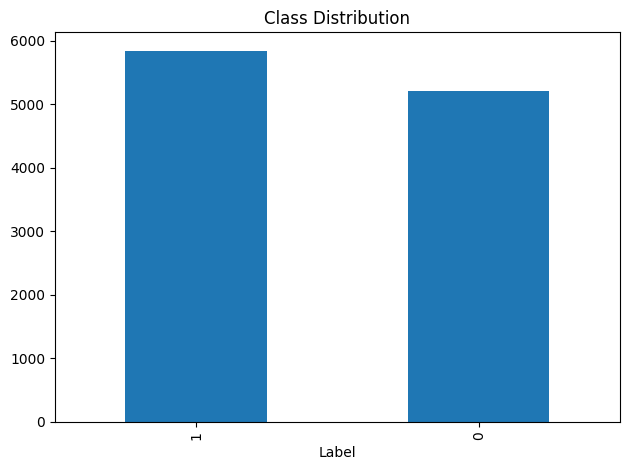

In [ ]:
print("\n===== CLASS DISTRIBUTION =====")
print(df['Label'].value_counts())
print(df['Label'].value_counts(normalize=True))

plt.figure()
df['Label'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.tight_layout()
plt.show()

## 4. STATISTICS + RANGE

In [ ]:
print("\n===== DESCRIBE =====")
print(df.describe())

print("\n===== RANGE CHECK =====")
for col in df.columns:
    if col != 'Label':
        print(f"{col}: min={df[col].min()}, max={df[col].max()}")


===== DESCRIBE =====
       total_packets   total_bytes  flow_duration_sec  bytes_per_sec  \
count   11051.000000  11051.000000       11051.000000   11051.000000   
mean        0.253560      0.198715           0.338138      -0.133229   
std         0.529757      0.655312           0.452237       0.474152   
min        -0.213031     -0.444029          -0.013963      -0.775762   
25%        -0.213031     -0.444029          -0.013313      -0.770331   
50%         0.000000      0.000000           0.006443      -0.017841   
75%         0.786969      0.555971           0.986623       0.217513   
max         1.945976      2.645154           1.130375       0.655342   

       pkts_per_sec  pkt_len_mean   pkt_len_std   pkt_len_min   pkt_len_max  \
count  11051.000000  11051.000000  11051.000000  11051.000000  11051.000000   
mean       0.008883      0.811842      0.523774      0.534662      0.892152   
std        0.508260      1.247155      0.697708      1.017910      1.424318   
min       -0.

## 5. SKEWNESS + KURTOSIS

In [ ]:
print("\n===== SKEWNESS =====")
print(df.skew())



===== SKEWNESS =====
total_packets             0.704190
total_bytes               1.230628
flow_duration_sec         0.709644
bytes_per_sec            -0.191969
pkts_per_sec              0.288426
pkt_len_mean              1.650166
pkt_len_std               0.944601
pkt_len_min               1.130752
pkt_len_max               1.582584
iat_mean                  0.780049
iat_std                   1.082833
iat_min                   1.388462
iat_max                   0.995206
syn_count                 0.638805
ack_count                 0.678794
fin_count                 1.992416
rst_count                 0.756882
syn_ack_ratio            -0.169127
ttl_mean                  0.810114
window_size_mean          0.093764
retransmission_count      6.351061
proto_tcp                -0.815265
proto_udp                 0.821201
proto_icmp               30.301271
proto_other             105.123737
Label                    -0.114036
dtype: float64


| Category          | Features                                               | Interpretation                                   |
| ----------------- | ------------------------------------------------------ | ------------------------------------------------ |
| Highly Skewed     | retransmission_count, proto_icmp, proto_other          | Rare or sparse events (mostly zeros, few spikes) |
| Moderately Skewed | pkt_len_mean, pkt_len_max, iat_min, fin_count          | Uneven distribution, common in network traffic   |
| Slightly Skewed   | total_packets, flow_duration_sec, syn_count, ack_count | Mild imbalance, acceptable                       |
| Near Symmetric    | window_size_mean, bytes_per_sec, syn_ack_ratio         | Well-balanced distribution                       |


## 6. CORRELATION WITH LABEL

In [ ]:
print("\n===== FEATURE IMPORTANCE (CORRELATION) =====")
corr = df.corr(numeric_only=True)['Label'].abs().sort_values(ascending=False)
print(corr)


===== FEATURE IMPORTANCE (CORRELATION) =====
Label                   1.000000
syn_ack_ratio           0.983322
pkt_len_std             0.794760
proto_tcp               0.710537
rst_count               0.709832
proto_udp               0.708584
pkt_len_mean            0.688860
ttl_mean                0.683907
pkt_len_max             0.662950
syn_count               0.637933
pkt_len_min             0.554670
iat_min                 0.499616
fin_count               0.445390
iat_mean                0.426774
flow_duration_sec       0.400613
iat_std                 0.357913
iat_max                 0.294231
window_size_mean        0.272098
ack_count               0.227050
total_bytes             0.193235
retransmission_count    0.179680
bytes_per_sec           0.164002
total_packets           0.113778
pkts_per_sec            0.045309
proto_icmp              0.034904
proto_other             0.010071
Name: Label, dtype: float64


| Category             | Features                                           | Interpretation                            |
| -------------------- | -------------------------------------------------- | ----------------------------------------- |
| Very High Importance | syn_ack_ratio (0.98)                               | Extremely strong predictor of class       |
| High Importance      | pkt_len_std, proto_tcp, rst_count, proto_udp       | Strong indicators of traffic behavior     |
| Moderate Importance  | pkt_len_mean, ttl_mean, syn_count, pkt_len_min     | Contribute meaningfully to classification |
| Low Importance       | total_packets, bytes_per_sec, retransmission_count | Limited influence                         |
| Very Low Importance  | proto_icmp, proto_other                            | Minimal contribution                      |


## 8. FEATURE SEPARATION (CLASS-WISE)


===== CLASS-WISE MEAN DIFFERENCE =====
pkt_len_max             1.891485
pkt_len_mean            1.720941
iat_min                 1.561326
pkt_len_min             1.130990
pkt_len_std             1.110771
syn_ack_ratio           0.952781
ttl_mean                0.701415
proto_tcp               0.659053
proto_udp               0.656558
rst_count               0.588934
syn_count               0.507921
iat_mean                0.393063
flow_duration_sec       0.362916
iat_std                 0.362706
fin_count               0.339744
window_size_mean        0.332329
iat_max                 0.297408
total_bytes             0.253658
ack_count               0.236499
bytes_per_sec           0.155769
total_packets           0.120739
retransmission_count    0.083734
pkts_per_sec            0.046130
proto_icmp              0.002303
proto_other             0.000192
dtype: float64


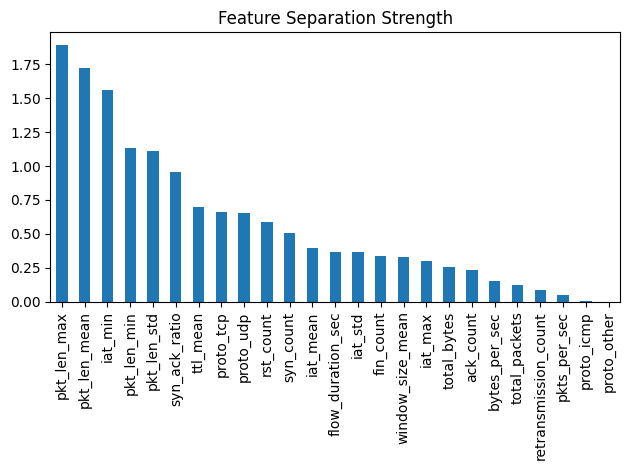

In [ ]:
print("\n===== CLASS-WISE MEAN DIFFERENCE =====")

class_means = df.groupby('Label').mean()
diff = (class_means.loc[1] - class_means.loc[0]).abs().sort_values(ascending=False)

print(diff)

plt.figure()
diff.plot(kind='bar')
plt.title("Feature Separation Strength")
plt.tight_layout()
plt.show()

| Category          | Observation                                                                                                                            |
| ----------------- | -------------------------------------------------------------------------------------------------------------------------------------- |
| High Importance   | Packet length features and inter-arrival time (e.g., pkt_len_max, pkt_len_mean, iat_min) show the strongest separation between classes |
| Medium Importance | Features such as ttl_mean and syn_ack_ratio contribute moderately to classification                                                    |
| Low Importance    | Protocol-related features and some rate-based features show minimal separation                                                         |
| Overall Insight   | Only a subset of features significantly contributes to distinguishing normal and attack traffic                                        |


## 9. DISTRIBUTION OVERLAY (VERY IMPORTANT)

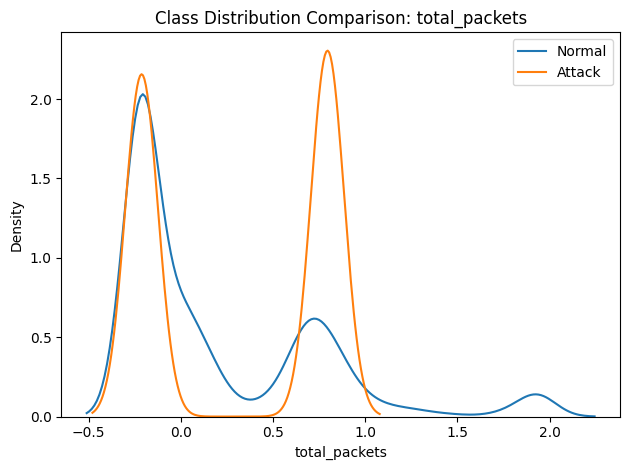

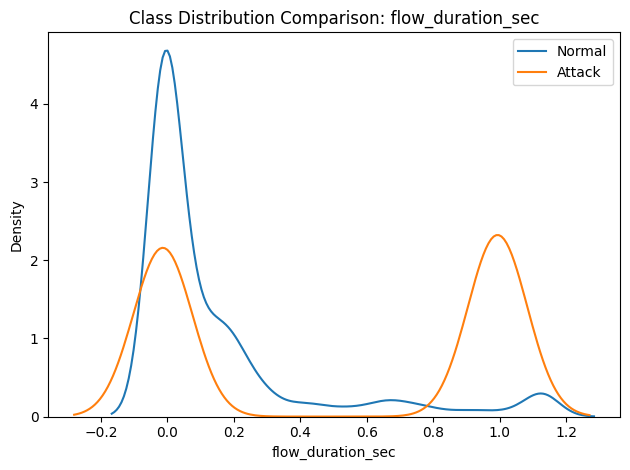

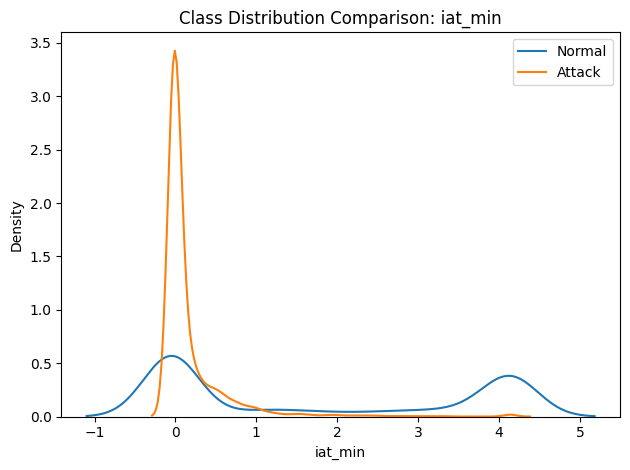

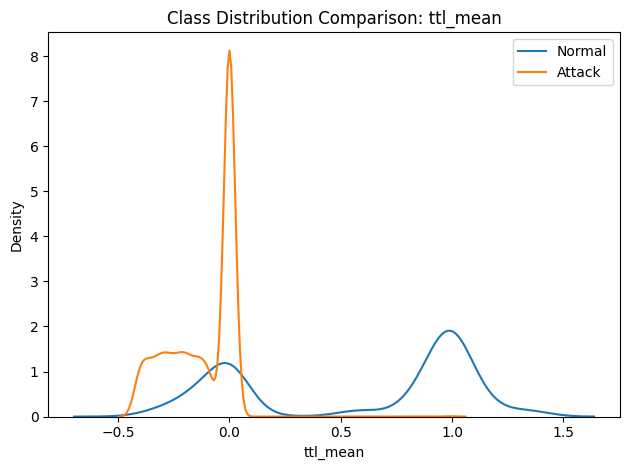

/tmp/ipykernel_6379/3420054561.py:13: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df[df['Label'] == 1][col], label='Attack')


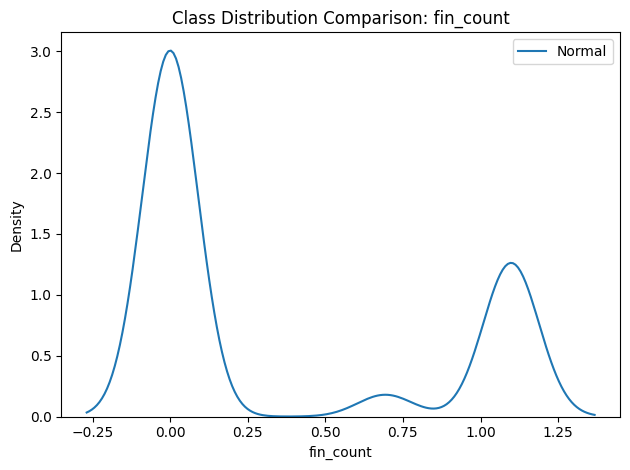

In [ ]:
features = [
    'total_packets',
    'flow_duration_sec',
    'iat_min',
    'ttl_mean',
    'fin_count'
]

for col in features:
    plt.figure()

    sns.kdeplot(df[df['Label'] == 0][col], label='Normal')
    sns.kdeplot(df[df['Label'] == 1][col], label='Attack')

    plt.title(f"Class Distribution Comparison: {col}")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 10. OUTLIER PERCENTAGE

In [ ]:
print("\n===== OUTLIER PERCENTAGE (IQR METHOD) =====")

for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    percentage = outliers / len(df) * 100

    print(f"{col}: {percentage:.2f}% outliers")


===== OUTLIER PERCENTAGE (IQR METHOD) =====
total_packets: 0.00% outliers
flow_duration_sec: 0.00% outliers
iat_min: 19.34% outliers
ttl_mean: 0.00% outliers
fin_count: 15.28% outliers


## 11. PCA VISUALIZATION (SEPARABILITY)

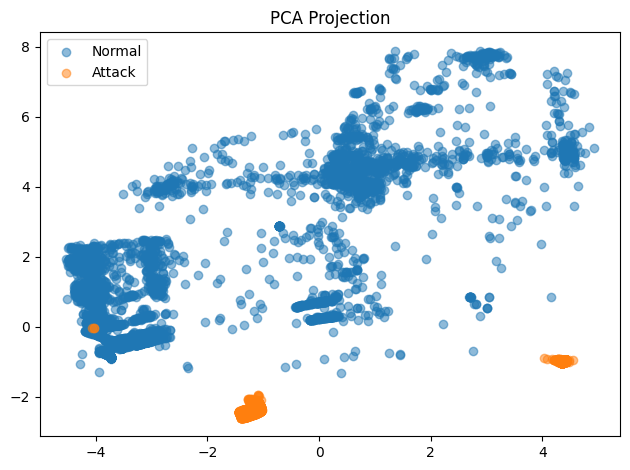

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure()
plt.scatter(X_pca[y == 0, 0], X_pca[y == 0, 1], label='Normal', alpha=0.5)
plt.scatter(X_pca[y == 1, 0], X_pca[y == 1, 1], label='Attack', alpha=0.5)
plt.title("PCA Projection")
plt.legend()
plt.tight_layout()
plt.show()

| Aspect                   | Observation                                               |
| ------------------------ | --------------------------------------------------------- |
| Dimensionality Reduction | High-dimensional features projected into 2D using PCA     |
| Attack Distribution      | Attack samples form tight, distinct clusters              |
| Normal Distribution      | Normal samples are more spread and diverse                |
| Class Separation         | Clear visual separation between normal and attack traffic |
| Overlap                  | Minor overlap exists, indicating some complexity          |


## 12. FEATURE REDUNDANCY (HIGH CORRELATION)

In [ ]:
print("\n===== HIGHLY CORRELATED FEATURES (>0.85) =====")

corr_matrix = df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

for col in upper.columns:
    high_corr = upper[col][upper[col] > 0.85]
    if not high_corr.empty:
        print(f"{col} correlated with:\n{high_corr}")


===== HIGHLY CORRELATED FEATURES (>0.85) =====
total_bytes correlated with:
total_packets    0.923675
Name: total_bytes, dtype: float64
bytes_per_sec correlated with:
flow_duration_sec    0.890935
Name: bytes_per_sec, dtype: float64
pkts_per_sec correlated with:
bytes_per_sec    0.96484
Name: pkts_per_sec, dtype: float64
pkt_len_std correlated with:
pkt_len_mean    0.917324
Name: pkt_len_std, dtype: float64
pkt_len_max correlated with:
pkt_len_mean    0.957848
pkt_len_std     0.940034
Name: pkt_len_max, dtype: float64
iat_mean correlated with:
flow_duration_sec    0.958623
bytes_per_sec        0.911960
Name: iat_mean, dtype: float64
iat_std correlated with:
flow_duration_sec    0.951205
bytes_per_sec        0.851337
iat_mean             0.947336
Name: iat_std, dtype: float64
iat_max correlated with:
flow_duration_sec    0.952437
bytes_per_sec        0.861560
iat_mean             0.936497
iat_std              0.982289
Name: iat_max, dtype: float64
syn_count correlated with:
flow_durati

| Category          | Features Involved                              | Interpretation                              |
| ----------------- | ---------------------------------------------- | ------------------------------------------- |
| Flow Size         | total_bytes ↔ total_packets                    | Both represent traffic volume               |
| Rate-Based        | bytes_per_sec, pkts_per_sec, flow_duration_sec | Derived from same time/volume relationships |
| Packet Length     | pkt_len_mean, pkt_len_std, pkt_len_max         | Different statistics of same distribution   |
| Timing (IAT)      | iat_mean, iat_std, iat_max, flow_duration_sec  | All describe temporal behavior of flows     |
| TCP Flags         | syn_count, ack_count, rst_count                | Related to connection behavior              |
| Protocol Encoding | proto_tcp ↔ proto_udp                          | One-hot encoded, mutually exclusive         |
| Label Relation    | syn_ack_ratio ↔ Label (0.98)                   | Very strong predictive feature              |


## 13. FINAL INTERPRETABLE TABLE

In [ ]:
summary = pd.DataFrame({
    "Mean_Normal": df[df['Label'] == 0].mean(),
    "Mean_Attack": df[df['Label'] == 1].mean(),
    "Difference": diff
})

print("\n===== FINAL FEATURE SUMMARY =====")
print(summary.sort_values(by="Difference", ascending=False))


===== FINAL FEATURE SUMMARY =====
                      Mean_Normal  Mean_Attack  Difference
pkt_len_max              1.891724     0.000239    1.891485
pkt_len_mean             1.721289     0.000348    1.720941
iat_min                  1.726978     0.165652    1.561326
pkt_len_min              1.132344     0.001354    1.130990
pkt_len_std              1.110771     0.000000    1.110771
syn_ack_ratio           -0.951320     0.001460    0.952781
ttl_mean                 0.582542    -0.118872    0.701415
proto_tcp                0.340434     0.999486    0.659053
proto_udp                0.657072     0.000514    0.656558
rst_count               -0.193647     0.395287    0.588934
syn_count               -0.112000     0.395921    0.507921
iat_mean                 0.110952     0.504015    0.393063
flow_duration_sec        0.146352     0.509268    0.362916
iat_std                  0.158038     0.520744    0.362706
fin_count                0.339744     0.000000    0.339744
window_size_mean     